<a href="https://colab.research.google.com/github/stephanie465337/Data-Science-Portfolio-C21/blob/main/3c_Feature_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Selection


Feature selection is the process of determining what features to include in your model. Why do we need feature selection?


*   To prevent overfitting - models with more features are more prone to overfitting
*   To simplify our model - simpler models are easier to interpret and debug
*   To reduce computation time - models run faster with less features


There are several ways we can perform feature selection
1. Filter methods
2. Wrapper methods such as forward selection (there are known issues with some of these methods)
3. Regularization methods (these are discussed in more detail in another lecture)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

## Read in Data

In [ ]:
#Read in data
url = "http://ddc-datascience.s3.amazonaws.com/CarPrice_Assignment.csv"
cars = pd.read_csv( url )
cars.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
cars.shape

(205, 26)

In [ ]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [ ]:
cars.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
car_ID,205.0,103.000000,59.322565,1.00,52.00,103.00,154.00,205.00
symboling,205.0,0.834146,1.245307,-2.00,0.00,1.00,2.00,3.00
wheelbase,205.0,98.756585,6.021776,86.60,94.50,97.00,102.40,120.90
carlength,205.0,174.049268,12.337289,141.10,166.30,173.20,183.10,208.10
carwidth,205.0,65.907805,2.145204,60.30,64.10,65.50,66.90,72.30
carheight,205.0,53.724878,2.443522,47.80,52.00,54.10,55.50,59.80
curbweight,205.0,2555.565854,520.680204,1488.00,2145.00,2414.00,2935.00,4066.00
enginesize,205.0,126.907317,41.642693,61.00,97.00,120.00,141.00,326.00
boreratio,205.0,3.329756,0.270844,2.54,3.15,3.31,3.58,3.94
stroke,205.0,3.255415,0.313597,2.07,3.11,3.29,3.41,4.17


## Data Cleaning

In [ ]:
cars["price"].sort_values(ascending = False)

,price
74,45400.0
16,41315.0
73,40960.0
128,37028.0
17,36880.0
...,...
76,5389.0
150,5348.0
50,5195.0
18,5151.0


In [ ]:
cars.nunique().sort_values(ascending = False)

,0
car_ID,205
price,189
curbweight,171
CarName,147
carlength,75
horsepower,59
wheelbase,53
carheight,49
carwidth,44
enginesize,44


In [ ]:
#Drop car_ID column
cars.drop('car_ID', inplace = True, axis = 1)

In [ ]:
#Look at CarName column
cars['CarName'].value_counts()

,count
CarName,
peugeot 504,6
toyota corolla,6
toyota corona,6
subaru dl,4
mitsubishi outlander,3
...,...
volkswagen super beetle,1
volkswagen rabbit custom,1
volvo 245,1


In [ ]:
#Keep just the name of the car manufacturer
car_split = lambda x: x.split(" ")[0]

def car_split(x):
  return x.split(" ")[0]

cars['carCompany'] = cars['CarName'].apply(lambda x: x.split(" ")[0])

# pd.Series([ x.split(" ")[0] for x in cars['CarName'] ][:10])

# cars['CarName'].apply(lambda x: x.split(" ")[0])


In [ ]:
cars['carCompany'].value_counts()

,count
carCompany,
toyota,31
nissan,17
mazda,15
honda,13
mitsubishi,13
subaru,12
volvo,11
peugeot,11
dodge,9


In [ ]:
# Fix spelling
# cars['carCompany'] = cars['carCompany'].str.replace('vw', 'volkswagen')
# cars['carCompany'] = cars['carCompany'].str.replace('vokswagen', 'volkswagen')
# cars['carCompany'] = cars['carCompany'].str.replace('porcshce', 'porsche')
# cars['carCompany'] = cars['carCompany'].str.replace('maxda', 'mazda')
# cars['carCompany'] = cars['carCompany'].str.replace('toyouta', 'toyota')
# cars['carCompany'] = cars['carCompany'].str.replace('Nissan', 'nissan')

In [ ]:
#Create mapping between incorrect and correct spelling
spelling_dict={
  'alfa-romero': 'alfa-romeo',
  'maxda'      : 'mazda',
  'Nissan'     : 'nissan',
  'porcshce'   : 'porsche',
  'toyouta'    : 'toyota',
  'vw'         : 'volkswagen',
  'vokswagen'  : 'volkswagen',
}

In [ ]:
#Fix spelling
for k, v in spelling_dict.items():
  cars['carCompany'] = cars['carCompany'].str.replace(k,v)

cars['carCompany'].value_counts()

,count
carCompany,
toyota,32
nissan,18
mazda,17
mitsubishi,13
honda,13
subaru,12
volkswagen,12
volvo,11
peugeot,11


In [ ]:
#Drop carname column
cars.drop('CarName', axis = 1, inplace = True)

In [ ]:
cars.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,carCompany
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romeo
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romeo
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romeo
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [ ]:
cars['doornumber'].value_counts(), cars['cylindernumber'].value_counts()

(doornumber
 4    115
 2     90
 Name: count, dtype: int64,
 cylindernumber
 4     159
 6      24
 5      11
 8       5
 2       4
 12      1
 3       1
 Name: count, dtype: int64)

In [ ]:
#Change doornumber and cylindernumber to numeric form
text_to_number = {
  'two'   :  "2",
  'three' :  "3",
  'four'  :  "4",
  'five'  :  "5",
  'six'   :  "6",
  'eight' :  "8",
  'twelve': "12",
}

cars['doornumber'] = cars['doornumber'].replace(text_to_number).astype(int)
cars['cylindernumber'] = cars['cylindernumber'].replace(text_to_number).astype(int)

cars[['doornumber','cylindernumber']].head()

,doornumber,cylindernumber
0,2,4
1,2,4
2,2,6
3,4,4
4,4,5


In [ ]:
cars.dtypes.sort_values()

,0
symboling,int64
highwaympg,int64
citympg,int64
doornumber,int64
peakrpm,int64
horsepower,int64
enginesize,int64
cylindernumber,int64
curbweight,int64
price,float64


In [ ]:
#Pull out object data types
cars_categorical = cars.select_dtypes(include = ['object'])
cars_categorical.head()

,fueltype,aspiration,carbody,drivewheel,enginelocation,enginetype,fuelsystem,carCompany
0,gas,std,convertible,rwd,front,dohc,mpfi,alfa-romeo
1,gas,std,convertible,rwd,front,dohc,mpfi,alfa-romeo
2,gas,std,hatchback,rwd,front,ohcv,mpfi,alfa-romeo
3,gas,std,sedan,fwd,front,ohc,mpfi,audi
4,gas,std,sedan,4wd,front,ohc,mpfi,audi


In [ ]:
for col in cars_categorical.columns:
  print(col, cars_categorical[col].unique())

fueltype ['gas' 'diesel']
aspiration ['std' 'turbo']
carbody ['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']
drivewheel ['rwd' 'fwd' '4wd']
enginelocation ['front' 'rear']
enginetype ['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf' 'dohcv']
fuelsystem ['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi']
carCompany ['alfa-romeo' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'buick' 'mercury' 'mitsubishi' 'nissan' 'peugeot' 'plymouth'
 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen' 'volvo']


In [ ]:
cars_categorical.nunique()

,0
fueltype,2
aspiration,2
carbody,5
drivewheel,3
enginelocation,2
enginetype,7
fuelsystem,8
carCompany,22


In [ ]:
cars_categorical.nunique().sum()

np.int64(51)

In [ ]:
#One hot encode these categories
cars_encoded = pd.get_dummies(cars_categorical) #dtype='int'
cars_encoded.head()

,fueltype_diesel,fueltype_gas,aspiration_std,aspiration_turbo,carbody_convertible,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,drivewheel_4wd,...,carCompany_nissan,carCompany_peugeot,carCompany_plymouth,carCompany_porsche,carCompany_renault,carCompany_saab,carCompany_subaru,carCompany_toyota,carCompany_volkswagen,carCompany_volvo
0,False,True,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,True,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,True,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,True,True,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
cars_encoded.shape

(205, 51)

In [ ]:
cars_categorical.shape

(205, 8)

In [ ]:
#Combine encoded dataframe to data frame with just numeric values
cars_numerical = cars.select_dtypes(include = ['int64', 'float64'])
cars_numerical.shape

(205, 17)

In [ ]:
cars_combined = pd.concat([cars_numerical, cars_encoded], axis = 1)
cars_combined.head()

,symboling,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,...,carCompany_nissan,carCompany_peugeot,carCompany_plymouth,carCompany_porsche,carCompany_renault,carCompany_saab,carCompany_subaru,carCompany_toyota,carCompany_volkswagen,carCompany_volvo
0,3,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,...,False,False,False,False,False,False,False,False,False,False
1,3,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,...,False,False,False,False,False,False,False,False,False,False
2,1,2,94.5,171.2,65.5,52.4,2823,6,152,2.68,...,False,False,False,False,False,False,False,False,False,False
3,2,4,99.8,176.6,66.2,54.3,2337,4,109,3.19,...,False,False,False,False,False,False,False,False,False,False
4,2,4,99.4,176.6,66.4,54.3,2824,5,136,3.19,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
cars_combined.shape

(205, 68)

In [ ]:
cars_combined.dtypes.value_counts()

,count
bool,51
int64,9
float64,8


## Processing

First, we will fit a model with all predictors.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [ ]:
#Split into Target and Features
X = cars_combined.drop('price', axis = 1)
y = cars_combined['price']

In [ ]:
#Perform CV
n = 500
results = np.zeros(n)
for idx in range(n):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25)
  model = LinearRegression()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  results[idx] = np.sqrt(mean_squared_error(y_test,y_pred))

print(f"CV RMSE: {results.mean().round(2)}")
print(f"Number of Predictors: {len(X.columns)}")

CV RMSE: 2648.22
Number of Predictors: 67


## Feature Selection

## Filter Methods
With filter methods, we will calculate a statistical metric for each column. Based on that metric, it will be decided whether that feature will be kept or removed from our predictive model. *Note*: the choice of statistical metric depends on the data type of the feature.

**Pros**: Easy to implement

**Cons**: Does not account for interactions between features

Image from [Toward Data Science:](https://towardsdatascience.com/learn-how-to-do-feature-selection-the-right-way-61bca8557bef)

![An image](https://miro.medium.com/max/1400/1*tzfWABEHK9-4SOaSl1mdRA.png)


### Numerical Predictors & Numerical Response - Pearson Correlation Coefficient

In [ ]:
#Look at numerical predictors
cars_numerical.head()

,symboling,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,2,94.5,171.2,65.5,52.4,2823,6,152,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,4,99.8,176.6,66.2,54.3,2337,4,109,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,4,99.4,176.6,66.4,54.3,2824,5,136,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
cars_numerical.shape

(205, 17)

In [ ]:
#Sort correlations w/ price
cars_numerical.corr()['price'].abs().sort_values(ascending = False)

,price
price,1.000000
enginesize,0.874145
curbweight,0.835305
horsepower,0.808139
carwidth,0.759325
cylindernumber,0.718305
highwaympg,0.697599
citympg,0.685751
carlength,0.682920
wheelbase,0.577816


#### Correlation bar graph


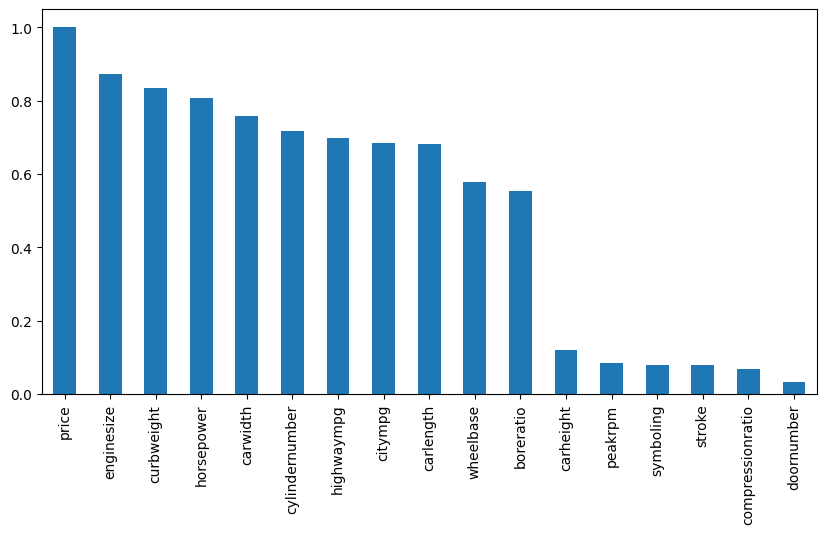

In [ ]:
#Plot result
cars_numerical.corr()['price'].abs().sort_values(ascending = False).plot(kind = 'bar', figsize = (10,5)) ;

WARNING: The correlation coefficient only measures the strength of the linear relationship between two variables. If the relationship is nonlinear, it may not be reflected in the correlation coefficient.

Example from [Toward Data Science:](https://towardsdatascience.com/learn-how-to-do-feature-selection-the-right-way-61bca8557bef)
![An image](https://miro.medium.com/max/1400/1*cY24YPkTGmuzaSaUmdTbmw.png)

In [ ]:
#Fit linear regression model w/ just continuous predictors highly correlated with response
corrs = cars_numerical.corr()['price'].abs().sort_values(ascending = False)
keep = corrs[(corrs>.2) & (corrs <1)]
keep

,price
enginesize,0.874145
curbweight,0.835305
horsepower,0.808139
carwidth,0.759325
cylindernumber,0.718305
highwaympg,0.697599
citympg,0.685751
carlength,0.682920
wheelbase,0.577816
boreratio,0.553173


In [ ]:
X_corr = X[keep.index]
X_corr.head()

,enginesize,curbweight,horsepower,carwidth,cylindernumber,highwaympg,citympg,carlength,wheelbase,boreratio
0,130,2548,111,64.1,4,27,21,168.8,88.6,3.47
1,130,2548,111,64.1,4,27,21,168.8,88.6,3.47
2,152,2823,154,65.5,6,26,19,171.2,94.5,2.68
3,109,2337,102,66.2,4,30,24,176.6,99.8,3.19
4,136,2824,115,66.4,5,22,18,176.6,99.4,3.19


In [ ]:
#Combine correlated numerical predictors with all encoded categorical predictors
X = pd.concat([X_corr, cars_encoded], axis = 1)
X.head()

,enginesize,curbweight,horsepower,carwidth,cylindernumber,highwaympg,citympg,carlength,wheelbase,boreratio,...,carCompany_nissan,carCompany_peugeot,carCompany_plymouth,carCompany_porsche,carCompany_renault,carCompany_saab,carCompany_subaru,carCompany_toyota,carCompany_volkswagen,carCompany_volvo
0,130,2548,111,64.1,4,27,21,168.8,88.6,3.47,...,False,False,False,False,False,False,False,False,False,False
1,130,2548,111,64.1,4,27,21,168.8,88.6,3.47,...,False,False,False,False,False,False,False,False,False,False
2,152,2823,154,65.5,6,26,19,171.2,94.5,2.68,...,False,False,False,False,False,False,False,False,False,False
3,109,2337,102,66.2,4,30,24,176.6,99.8,3.19,...,False,False,False,False,False,False,False,False,False,False
4,136,2824,115,66.4,5,22,18,176.6,99.4,3.19,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
X.shape

(205, 61)

In [ ]:
#Perform CV
n = 500
results = np.zeros(n)
for idx in range(n):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25)
  model = LinearRegression()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  results[idx] = np.sqrt(mean_squared_error(y_test,y_pred))

print(f"CV RMSE: {results.mean().round(2)}")
print(f"Number of Predictors: {len(X.columns)}")

CV RMSE: 2510.71
Number of Predictors: 61


### ANOVA - Categorical Predictors & Numerical Response
ANOVA works by testing if the means of different categories are statistically different. For example, it would test to see if the mean price for BMWs is statistically different from the mean price of Buicks.

It is based on the following two hypotheses
H0: Means of all groups are equal. (null hypothesis)
H1: At least one mean of the groups are different.

ANOVA calculates an F-Test for statistical signficance. The larger the value of the F-test, the more likely we are to reject the null hypothesis.

<Axes: >

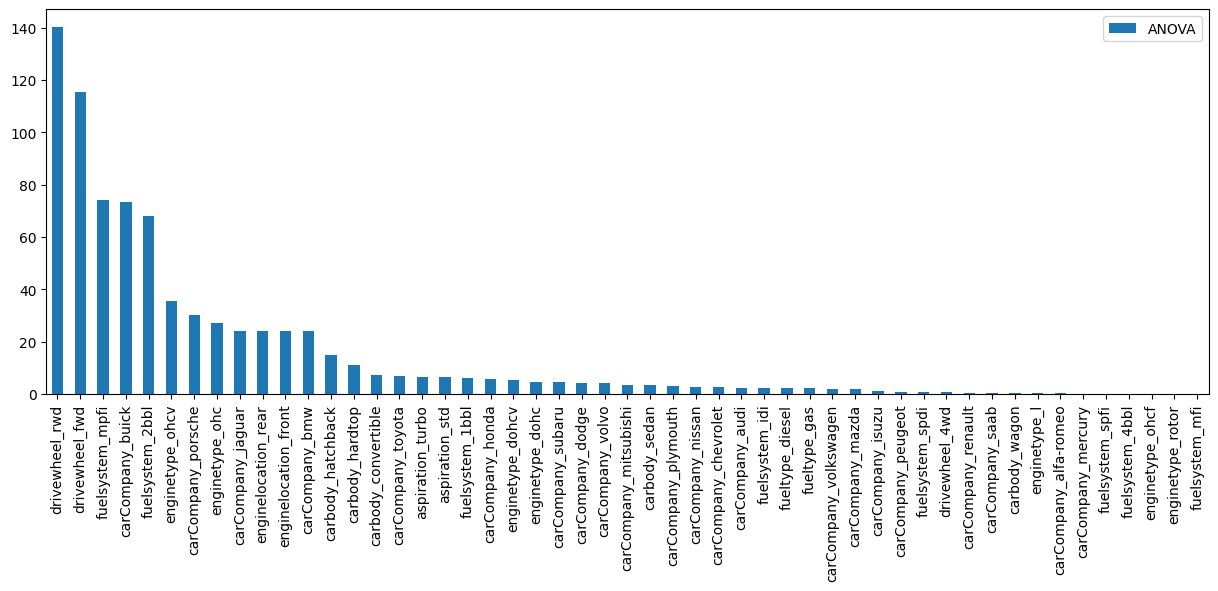

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression

fvalue_selector = SelectKBest(f_regression, k='all')  #Select features best ANOVA F-Values
fvalue_selector.fit_transform(cars_encoded, y)

#Plot results
results = pd.DataFrame({'ANOVA': fvalue_selector.scores_}, index = cars_encoded.columns)
results.sort_values(by = 'ANOVA', ascending = False).plot(kind = 'bar', figsize = (15,5))

In [ ]:
#Just keep the results with F-values greater than 20
anova = results.sort_values(by = 'ANOVA', ascending = False)
keep = anova['ANOVA'][anova['ANOVA'] > 20]
keep

,ANOVA
drivewheel_rwd,140.059236
drivewheel_fwd,115.353549
fuelsystem_mpfi,74.082624
carCompany_buick,73.311482
fuelsystem_2bbl,68.164246
enginetype_ohcv,35.539883
carCompany_porsche,30.145299
enginetype_ohc,27.295010
carCompany_jaguar,24.151792
enginelocation_rear,23.969740


In [ ]:
X_anova = X[keep.index]

In [ ]:
X_anova

,drivewheel_rwd,drivewheel_fwd,fuelsystem_mpfi,carCompany_buick,fuelsystem_2bbl,enginetype_ohcv,carCompany_porsche,enginetype_ohc,carCompany_jaguar,enginelocation_rear,enginelocation_front,carCompany_bmw,carbody_hatchback,carbody_hardtop,carbody_convertible,carCompany_toyota,aspiration_turbo,aspiration_std,fuelsystem_1bbl
0,True,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False
1,True,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False
2,True,False,True,False,False,True,False,False,False,False,True,False,True,False,False,False,False,True,False
3,False,True,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False
4,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,True,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False
201,True,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False
202,True,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False
203,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False


In [ ]:
X2 = pd.concat([X_anova, X_corr], axis = 1)
X2.head()

,drivewheel_rwd,drivewheel_fwd,fuelsystem_mpfi,carCompany_buick,fuelsystem_2bbl,enginetype_ohcv,carCompany_porsche,enginetype_ohc,carCompany_jaguar,enginelocation_rear,...,enginesize,curbweight,horsepower,carwidth,cylindernumber,highwaympg,citympg,carlength,wheelbase,boreratio
0,True,False,True,False,False,False,False,False,False,False,...,130,2548,111,64.1,4,27,21,168.8,88.6,3.47
1,True,False,True,False,False,False,False,False,False,False,...,130,2548,111,64.1,4,27,21,168.8,88.6,3.47
2,True,False,True,False,False,True,False,False,False,False,...,152,2823,154,65.5,6,26,19,171.2,94.5,2.68
3,False,True,True,False,False,False,False,True,False,False,...,109,2337,102,66.2,4,30,24,176.6,99.8,3.19
4,False,False,True,False,False,False,False,True,False,False,...,136,2824,115,66.4,5,22,18,176.6,99.4,3.19


In [ ]:
(X_corr.shape, X_anova.shape, X.shape, X2.shape)

((205, 10), (205, 19), (205, 61), (205, 29))

In [ ]:
#Perform CV
n = 500
rmse_results = np.zeros(n)
for idx in range(n):
  X_train, X_test, y_train, y_test = train_test_split(X2,y,test_size=0.25)
  model = LinearRegression()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  rmse_results[idx] = np.sqrt(mean_squared_error(y_test,y_pred))
print(f"CV RMSE: {rmse_results.mean().round(2)}")
print(f"Number of Predictors: {len(X2.columns)}")

CV RMSE: 2457.12
Number of Predictors: 29


## Regularization

In [ ]:
from sklearn.linear_model import Lasso

Scale the data frame using the Standard Scaler

In [ ]:
cars_combined

,symboling,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,...,carCompany_nissan,carCompany_peugeot,carCompany_plymouth,carCompany_porsche,carCompany_renault,carCompany_saab,carCompany_subaru,carCompany_toyota,carCompany_volkswagen,carCompany_volvo
0,3,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,...,False,False,False,False,False,False,False,False,False,False
1,3,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,...,False,False,False,False,False,False,False,False,False,False
2,1,2,94.5,171.2,65.5,52.4,2823,6,152,2.68,...,False,False,False,False,False,False,False,False,False,False
3,2,4,99.8,176.6,66.2,54.3,2337,4,109,3.19,...,False,False,False,False,False,False,False,False,False,False
4,2,4,99.4,176.6,66.4,54.3,2824,5,136,3.19,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,4,109.1,188.8,68.9,55.5,2952,4,141,3.78,...,False,False,False,False,False,False,False,False,False,True
201,-1,4,109.1,188.8,68.8,55.5,3049,4,141,3.78,...,False,False,False,False,False,False,False,False,False,True
202,-1,4,109.1,188.8,68.9,55.5,3012,6,173,3.58,...,False,False,False,False,False,False,False,False,False,True
203,-1,4,109.1,188.8,68.9,55.5,3217,6,145,3.01,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
cars_combined_bak = cars_combined.copy()
cars_combined_bak.shape

(205, 68)

In [ ]:
#Restore
cars_combined = cars_combined_bak.copy()
cars_combined

,symboling,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,...,carCompany_nissan,carCompany_peugeot,carCompany_plymouth,carCompany_porsche,carCompany_renault,carCompany_saab,carCompany_subaru,carCompany_toyota,carCompany_volkswagen,carCompany_volvo
0,3,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,...,False,False,False,False,False,False,False,False,False,False
1,3,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,...,False,False,False,False,False,False,False,False,False,False
2,1,2,94.5,171.2,65.5,52.4,2823,6,152,2.68,...,False,False,False,False,False,False,False,False,False,False
3,2,4,99.8,176.6,66.2,54.3,2337,4,109,3.19,...,False,False,False,False,False,False,False,False,False,False
4,2,4,99.4,176.6,66.4,54.3,2824,5,136,3.19,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,4,109.1,188.8,68.9,55.5,2952,4,141,3.78,...,False,False,False,False,False,False,False,False,False,True
201,-1,4,109.1,188.8,68.8,55.5,3049,4,141,3.78,...,False,False,False,False,False,False,False,False,False,True
202,-1,4,109.1,188.8,68.9,55.5,3012,6,173,3.58,...,False,False,False,False,False,False,False,False,False,True
203,-1,4,109.1,188.8,68.9,55.5,3217,6,145,3.01,...,False,False,False,False,False,False,False,False,False,True


Use standard scaler to scale data set.

This data set is the cleaned without the feature selection from correlation.

In [ ]:
# %%capture --no-stdout
X_lasso = cars_combined.drop('price', axis = 1)
y_lasso = cars_combined['price']

#Specify values of alpha we want to try
alph = [50, 75, 100, 200, 300,]

#Create empty list to hold results
results_alpha = []

for i in alph:
  #Calculate CV RMSE
  n = 200
  results = np.zeros(n)

  for idx in range(n):
    #Train, test split
    X_train, X_test, y_train, y_test = train_test_split(X_lasso, y_lasso, test_size=0.25)

    #Standard scale only training features
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train = scaler.transform(X_train)

    #Scale testing features
    X_test = scaler.transform(X_test)

    #Create the model
    my_fit_lasso = Lasso(alpha = i, tol = .01, max_iter=10_000); #Looping through alpha

    #Fit regression
    my_fit_lasso.fit(X_train, y_train)

    #Predict
    y_pred = my_fit_lasso.predict(X_test)

    #Calculate and record performance metric
    results[idx] = np.sqrt(mean_squared_error(y_test,y_pred))

  results_alpha.append(results.mean())

results_df = pd.DataFrame({'Alpha': alph, 'RMSE': results_alpha})

In [ ]:
results_df.sort_values(by = 'RMSE')

,Alpha,RMSE
1,75,2370.998249
0,50,2378.493534
3,200,2410.995836
2,100,2429.744876
4,300,2545.510194


Get the Alpha that results in the lowest RMSE.

In [ ]:
results_df.sort_values(by = 'RMSE')["Alpha"][0]

np.int64(50)

In [ ]:
results_df.sort_values(by = 'RMSE')["Alpha"].iloc[0]

np.int64(100)

In [ ]:
alpha = results_df.sort_values(by = 'RMSE')["Alpha"].iloc[0]
alpha

np.int64(100)

In [ ]:
# %%capture --no-stdout
#Perform CV
n = 500
results = np.zeros(n)

for idx in range(n):
  #Train, test split
  X_train, X_test, y_train, y_test = train_test_split(X_lasso, y_lasso, test_size=0.25)

  #Standard scale only training features
  scaler = StandardScaler()
  scaler.fit(X_train)
  X_train = scaler.transform(X_train)

  #Scale testing features
  X_test = scaler.transform(X_test)

  #Create the model
  model = Lasso(alpha = alpha, tol = .01, max_iter=10000)

  #Fit regression
  model.fit(X_train, y_train)

  #Predict
  y_pred = model.predict(X_test)

  #Calculate and record performance metric
  results[idx] = np.sqrt(mean_squared_error(y_test,y_pred))

print(f"CV RMSE: {results.mean().round(2)}")
print(f"Number of Predictors: {sum(model.coef_ >0)}")

CV RMSE: 2362.7
Number of Predictors: 20


In [ ]:
X_lasso.shape

(205, 67)

In [ ]:
len(X_lasso.columns)

67

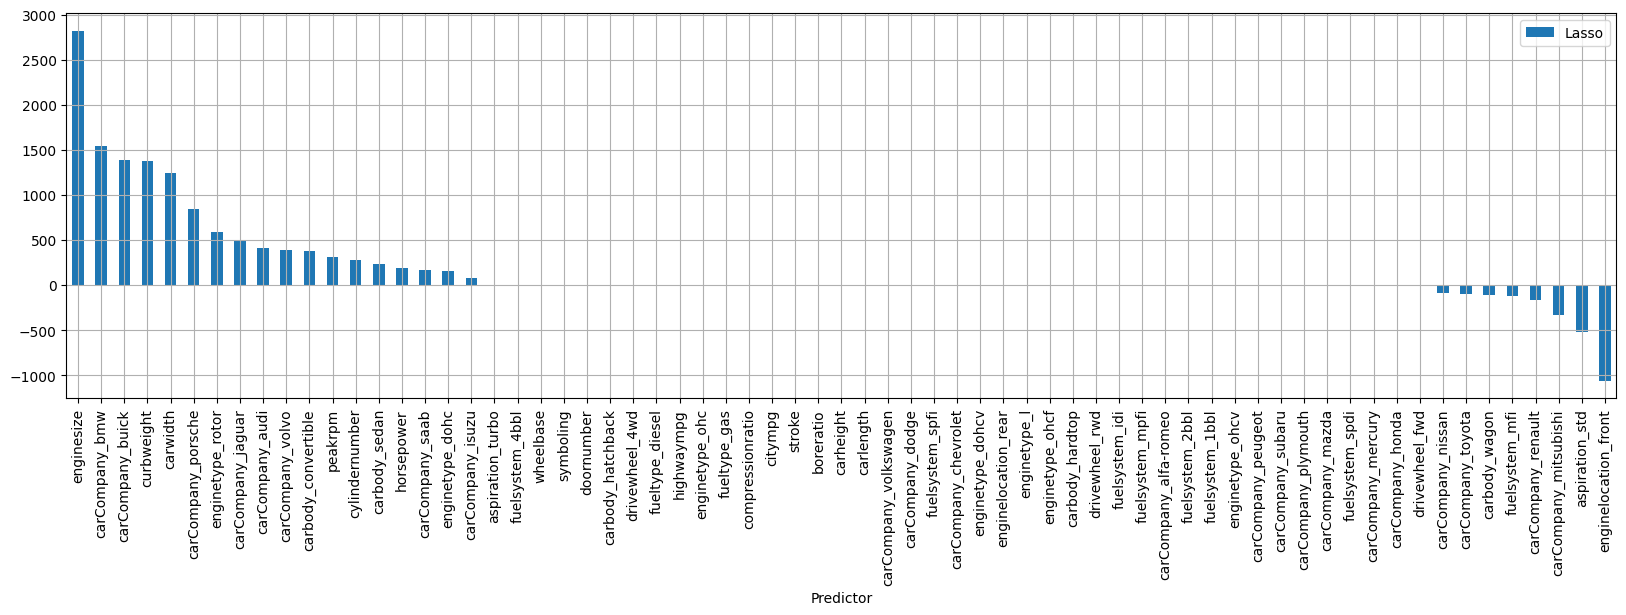

In [ ]:
#Plot model coefficients
model_results = pd.DataFrame()
model_results['Predictor'] = X_lasso.columns
model_results['Lasso'] = model.coef_
model_results.sort_values( by = ["Lasso"], ascending = False ).plot(
    x = 'Predictor',
    kind = 'bar',
    figsize = (20,5)
    )
plt.grid()

In [ ]:
model_results['Lasso'].abs().sort_values()

,Lasso
0,0.000000
1,0.000000
2,0.000000
3,0.000000
5,0.000000
...,...
4,1241.841603
6,1373.827470
48,1383.609806
47,1543.009081


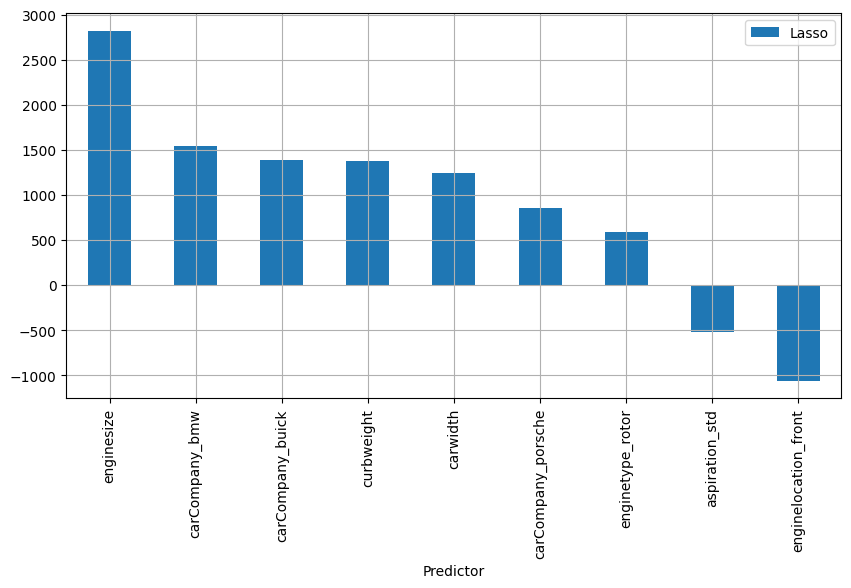

In [ ]:
#Plot parameters with coefficients greater than 0
greater_0 = model_results[(model_results['Lasso'] > 500 ) | (model_results['Lasso'] < -500 )]
greater_0.sort_values( by = ["Lasso"], ascending = False ).plot(x = 'Predictor', kind = 'bar', figsize = (10,5))
plt.grid()

In [ ]:
X_lasso[greater_0["Predictor"]]

,carwidth,curbweight,enginesize,aspiration_std,enginelocation_front,enginetype_rotor,carCompany_bmw,carCompany_buick,carCompany_porsche
0,64.1,2548,130,True,True,False,False,False,False
1,64.1,2548,130,True,True,False,False,False,False
2,65.5,2823,152,True,True,False,False,False,False
3,66.2,2337,109,True,True,False,False,False,False
4,66.4,2824,136,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...
200,68.9,2952,141,True,True,False,False,False,False
201,68.8,3049,141,False,True,False,False,False,False
202,68.9,3012,173,True,True,False,False,False,False
203,68.9,3217,145,False,True,False,False,False,False


## Leaky data


In [ ]:
X_lasso2 = X_lasso.copy()
X_lasso2.shape

(205, 67)

In [ ]:
X_lasso2["leaky"] = y_lasso
X_lasso2.shape

(205, 68)

In [ ]:
X_lasso2

,symboling,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,...,carCompany_peugeot,carCompany_plymouth,carCompany_porsche,carCompany_renault,carCompany_saab,carCompany_subaru,carCompany_toyota,carCompany_volkswagen,carCompany_volvo,leaky
0,3,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,...,False,False,False,False,False,False,False,False,False,13495.0
1,3,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,...,False,False,False,False,False,False,False,False,False,16500.0
2,1,2,94.5,171.2,65.5,52.4,2823,6,152,2.68,...,False,False,False,False,False,False,False,False,False,16500.0
3,2,4,99.8,176.6,66.2,54.3,2337,4,109,3.19,...,False,False,False,False,False,False,False,False,False,13950.0
4,2,4,99.4,176.6,66.4,54.3,2824,5,136,3.19,...,False,False,False,False,False,False,False,False,False,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,4,109.1,188.8,68.9,55.5,2952,4,141,3.78,...,False,False,False,False,False,False,False,False,True,16845.0
201,-1,4,109.1,188.8,68.8,55.5,3049,4,141,3.78,...,False,False,False,False,False,False,False,False,True,19045.0
202,-1,4,109.1,188.8,68.9,55.5,3012,6,173,3.58,...,False,False,False,False,False,False,False,False,True,21485.0
203,-1,4,109.1,188.8,68.9,55.5,3217,6,145,3.01,...,False,False,False,False,False,False,False,False,True,22470.0


In [ ]:
# %%capture --no-stdout
# Perform CV
n = 500
results = np.zeros(n)

for idx in range(n):
  #Train, test split
  X_train, X_test, y_train, y_test = train_test_split(X_lasso2, y_lasso, test_size=0.25)

  #Standard scale only training features
  scaler = StandardScaler()
  scaler.fit(X_train)
  X_train = scaler.transform(X_train)

  #Scale testing features
  X_test = scaler.transform(X_test)

  #Create the model
  model = Lasso(alpha = alpha, tol = .01, max_iter=10000)

  #Fit regression
  model.fit(X_train, y_train)

  #Predict
  y_pred = model.predict(X_test)

  #Calculate and record performance metric
  results[idx] = np.sqrt(mean_squared_error(y_test,y_pred))

print(f"CV RMSE: {results.mean().round(2)}")
print(f"Number of Predictors: {sum(model.coef_ >0)}")

CV RMSE: 108.49
Number of Predictors: 2
